# 02 - Feature Building (Polars Engine)

Produces `data/model_dataset/dataset.parquet` using the **new polars-based feature engine** in `src/features/`.

For the legacy pandas-based pipeline (kept as the parity oracle), see [`02_feature_building_legacy.ipynb`](02_feature_building_legacy.ipynb).

---

## Pipeline shape

Everything between raw bars and the final boundary-aligned dataset is encapsulated by a single call to `src.features.pipeline.run_pipeline()`. The stages it runs are:

1. **Base series** - `compute_base_series` (legacy; r, rho, clv, bodyfrac, vwap, ...)
2. **Derivatives base** (optional) - `compute_derivatives_base_series` (legacy)
3. **Bar-level features (Tier 1 + Tier 2)** - `FeatureEngine` runs every registered family in dependency order: lag, rolling, quantile, vol, candle, trend, activity, correlation, entropy, event, seasonality, derivatives, excursion, liquidity. ~1,250 columns.
4. **Data quality flags** - `compute_data_quality_flags_pl`
5. **Decision-boundary sample** - every M-th row
6. **Boundary stages** - `construct_labels_pl`, `compute_past_target_features_pl`, `compute_barrier_aware_features_pl`, `compute_block_features_pl`
7. **Warmup trim + drop NaN labels**
8. **Undef flags + per-feature imputation** - `create_undef_flags_and_impute_pl`

Stage W (sample weights) is appended after the pipeline using the legacy numpy-based `compute_training_weights` - kept as-is because it is pure numpy and gains nothing from porting.

## Outputs

- `data/model_dataset/dataset.parquet`
- `data/model_dataset/feature_list.json`
- `data/model_dataset/dataset_metadata.json`

---

## Where the legacy/new line is drawn

| Component | Source |
|---|---|
| Base series (raw -> r, rho, clv, ...) | `src.utils` (legacy, kept) |
| All Tier-1 / Tier-2 feature computation | `src.features.pipeline.run_pipeline` (new) |
| Boundary-stage transformations | `src.features.boundary` (new) |
| Data quality + impute | `src.features.quality` (new) |
| Sample weights | `src.utils.compute_training_weights` (legacy, kept) |
| Save / metadata helpers | `src.utils.save_*` (legacy, kept) |

Anything imported from `src.utils` below is legacy. Anything from `src.features.*` is the new package.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl

# Resolve repo root (notebook may run from notebooks/ or repo root).
ROOT = Path.cwd()
if not (ROOT / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
    if (ROOT.parent / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Could not locate repo root (docs/MINIMAL_PROJECT_SPEC_v2.md not found).')

sys.path.insert(0, str(ROOT))

# === Legacy imports (constants + base series + weights + IO helpers) ===
from src import utils

# === New package (the polars-based feature engine) ====================
from src.features.pipeline import run_pipeline

RAW_PARQUET = ROOT / 'data' / 'raw_data' / 'klines_1m.parquet'
OUT_DIR = ROOT / 'data' / 'model_dataset'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('OUT_DIR:', OUT_DIR)
print('Derivatives enabled:', utils.ENABLE_DERIVATIVES_FEATURES)


ROOT: C:\Users\vitil\OneDrive\Desktop\barrier_classifier
OUT_DIR: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset
Derivatives enabled: True


## Stage A: Load raw bars (and derivatives if enabled)

Joins the spot bars with all derivative streams the same way the legacy notebook does. The pipeline accepts a single pandas DataFrame indexed by tz-aware timestamp; if derivatives are enabled, the relevant columns must already be merged.


In [2]:
if not RAW_PARQUET.exists():
    raise RuntimeError('Missing data/raw_data/klines_1m.parquet. Run 01_data_download.ipynb first.')

df_raw = pd.read_parquet(RAW_PARQUET)
df_raw = df_raw.sort_index()
utils.assert_index_is_utc_datetime_index(df_raw, context='02_feature_building: df_raw')

if utils.ENABLE_DERIVATIVES_FEATURES:
    DERIV_DIR = ROOT / utils.DERIVATIVES_RAW_DIR
    df_fut = pd.read_parquet(DERIV_DIR / 'futures_klines_1m.parquet').sort_index()
    df_funding = pd.read_parquet(DERIV_DIR / 'funding_rate_1m.parquet').sort_index()
    df_metrics = pd.read_parquet(DERIV_DIR / 'futures_metrics_1m.parquet').sort_index()
    df_eoh = pd.read_parquet(DERIV_DIR / 'eoh_summary_1m.parquet').sort_index()
    df_bvol = pd.read_parquet(DERIV_DIR / 'bvol_index_1m.parquet').sort_index()

    df_raw = df_raw.join(
        df_fut[['close', 'volume', 'quote_volume', 'taker_buy_base', 'num_trades']].rename(
            columns={
                'close': 'close_fut',
                'volume': 'volume_fut',
                'quote_volume': 'quote_volume_fut',
                'taker_buy_base': 'taker_buy_base_fut',
                'num_trades': 'num_trades_fut',
            }
        ),
        how='left',
    )
    df_raw = df_raw.join(df_funding[['funding_rate']], how='left')
    df_raw = df_raw.join(df_metrics[['oi_usd']], how='left')
    df_raw = df_raw.join(
        df_eoh[['opt_oi', 'put_open_interest', 'call_open_interest', 'opt_volume', 'put_volume', 'call_volume']],
        how='left',
    )
    df_raw = df_raw.join(df_bvol[['bvol']], how='left')

print('Raw rows:', len(df_raw))
print('Raw range:', df_raw.index.min(), 'to', df_raw.index.max())


Raw rows: 525600
Raw range: 2025-01-01 00:01:00+00:00 to 2026-01-01 00:00:00+00:00


## Stage B: Run feature pipeline

One call. Produces the boundary-aligned dataset with labels, features, undef flags, and imputed values - bit-equal (rtol=1e-9) to the legacy `compute_*` chain output, ~10x faster on the polars backend.


In [3]:
df_final_pl = run_pipeline(
    df_raw,
    with_derivatives=utils.ENABLE_DERIVATIVES_FEATURES,
    p_hit_prior=0.5,
)

print('Final rows:', len(df_final_pl))
print('Final columns:', len(df_final_pl.columns))
print('Date range:', df_final_pl['ts'].min(), 'to', df_final_pl['ts'].max())
print('Base rate (y):', float(df_final_pl['y'].mean()))


Final rows: 25271
Final columns: 1303
Date range: 2025-01-15 00:01:00 to 2025-12-31 23:21:00
Base rate (y): 0.17905900043528156


## Stage W: Sample weights (legacy, kept as-is)

Pure numpy - no benefit to porting. Reads `m_k`, `phi`, `k` from the polars frame and returns weight arrays which are appended back as columns.


In [4]:
m_k = df_final_pl['m_k'].to_numpy()
phi = float(df_final_pl['phi'][0])
k_index = df_final_pl['k'].to_numpy()

w_combined, w_dist, w_time, weight_info = utils.compute_training_weights(
    m_k=m_k,
    phi=phi,
    use_dist=utils.WEIGHT_USE_BARRIER_DISTANCE,
    use_time=utils.WEIGHT_USE_TIME_DISCOUNT,
    w_max=utils.WEIGHT_DIST_W_MAX,
    q_tail=utils.WEIGHT_DIST_Q_TAIL,
    r=utils.WEIGHT_TIME_R,
    delta=utils.WEIGHT_TIME_DELTA,
    k_index=k_index,
    normalize=utils.WEIGHT_NORMALIZE,
)

df_final_pl = df_final_pl.with_columns([
    pl.Series('w_dist', w_dist),
    pl.Series('w_time', w_time),
    pl.Series('weight', w_combined),
])

n_capped = weight_info['barrier_distance']['n_capped']
oldest_weight = weight_info['time_discount']['oldest_weight']
effective_n = weight_info['combined']['effective_n']
print(f'Barrier-distance: range [{w_dist.min():.4f}, {w_dist.max():.4f}], capped {n_capped:,}')
print(f'Time-discount: oldest weight = {oldest_weight:.6f}')
print(f'Combined: range [{w_combined.min():.6f}, {w_combined.max():.4f}], mean = {w_combined.mean():.4f}')
print(f'Effective N: {effective_n:,.0f} / {len(w_combined):,}')


Barrier-distance: range [1.0000, 5.0000], capped 21
Time-discount: oldest weight = 1.000000
Combined: range [1.000000, 5.0000], mean = 1.6966
Effective N: 22,823 / 25,271


## Stage D: Save dataset + feature list + metadata

Same artifact contract as the legacy notebook: parquet for the wide dataset; JSON for the ordered feature list and metadata.


In [5]:
dataset_path = OUT_DIR / 'dataset.parquet'
feature_list_path = OUT_DIR / 'feature_list.json'
metadata_path = OUT_DIR / 'dataset_metadata.json'

df_final_pl.write_parquet(dataset_path)

LABEL_AUX_COLS = ['m_k', 'tau_k', 'phi']
WEIGHT_COLS = ['w_dist', 'w_time', 'weight']
DERIV_BASE_COLS = [
    'close_fut', 'volume_fut', 'quote_volume_fut', 'taker_buy_base_fut', 'num_trades_fut',
    'funding_rate', 'oi_usd', 'opt_oi', 'put_open_interest', 'call_open_interest',
    'opt_volume', 'put_volume', 'call_volume', 'bvol',
    'basis_abs', 'basis_pct', 'tb_ratio_fut', 'net_vol_fut', 'pcr_oi', 'pcr_vol',
]
RAW_COLS = [
    'open', 'high', 'low', 'close', 'volume', 'quote_volume',
    'num_trades', 'taker_buy_base', 'taker_buy_quote',
]
BASE_COLS = [
    'p', 'r', 'rho', 'r_oc', 'g', 'logvol', 'logtrades', 'logquotevol',
    'b', 'ofi', 'clv', 'bodyfrac', 'wickup', 'wickdn', 'vwap', 'vwapdev', 'qpertrade',
]
NON_FEATURE_COLS = set(['k', 'ts', 'y'] + LABEL_AUX_COLS + WEIGHT_COLS + DERIV_BASE_COLS + RAW_COLS + BASE_COLS)

feature_list = [c for c in df_final_pl.columns if c not in NON_FEATURE_COLS]

utils.save_feature_list(str(feature_list_path), feature_list)

metadata = {
    'SYMBOL': utils.SYMBOL,
    'INTERVAL': utils.INTERVAL,
    'START_YEAR': utils.START_YEAR,
    'START_MONTH': utils.START_MONTH,
    'END_YEAR': utils.END_YEAR,
    'END_MONTH': utils.END_MONTH,
    'M': utils.M,
    'ETA': utils.ETA,
    'C': utils.C,
    'PHI': utils.PHI,
    'EPS': utils.EPS,
    'WINDOWS_F': utils.WINDOWS_F,
    'LAGS_F': utils.LAGS_F,
    'WINDOWS_H': utils.WINDOWS_H,
    'VOL_PAIRS': utils.VOL_PAIRS,
    'N_WARMUP': utils.N_WARMUP,
    'K_WARMUP': utils.K_WARMUP,
    'label_aux_cols': LABEL_AUX_COLS,
    'weight_cols': WEIGHT_COLS,
    'non_feature_cols': sorted(NON_FEATURE_COLS),
    'n_rows': int(len(df_final_pl)),
    'date_range': [str(df_final_pl['ts'].min()), str(df_final_pl['ts'].max())],
    'feature_count': int(len(feature_list)),
    'pipeline': 'src.features.pipeline.run_pipeline',
    'weighting': weight_info,
}
utils.save_metadata(str(metadata_path), metadata)

print('Wrote:', dataset_path)
print('Wrote:', feature_list_path)
print('Wrote:', metadata_path)
print('Feature columns:', len(feature_list))


Wrote: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset.parquet
Wrote: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\feature_list.json
Wrote: C:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset_metadata.json
Feature columns: 1251


## Visualizations

Two quick sanity plots: target distribution and time-series view. Polars frame is converted to pandas only at the matplotlib boundary.


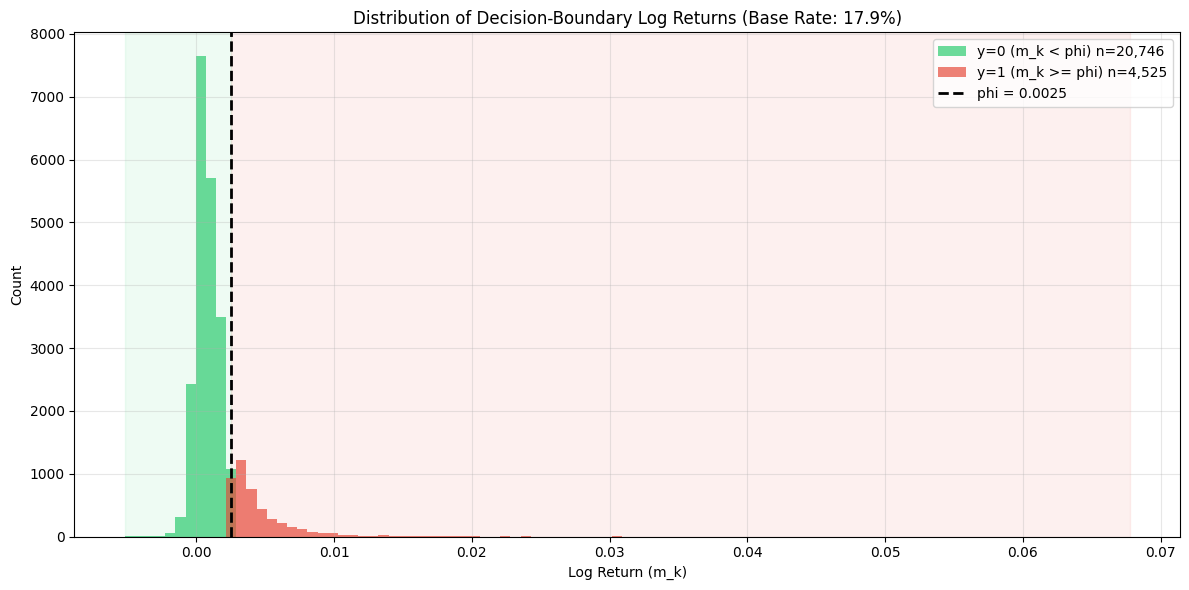

In [6]:
import matplotlib.pyplot as plt

df_final = df_final_pl.to_pandas()
m_k = df_final['m_k'].to_numpy()
y = df_final['y'].to_numpy()
phi = float(df_final['phi'].iloc[0])

bins = np.linspace(m_k.min(), m_k.max(), 100)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(m_k[y == 0], bins=bins, alpha=0.7, color='#2ecc71',
        label=f'y=0 (m_k < phi) n={int((y == 0).sum()):,}', edgecolor='none')
ax.hist(m_k[y == 1], bins=bins, alpha=0.7, color='#e74c3c',
        label=f'y=1 (m_k >= phi) n={int((y == 1).sum()):,}', edgecolor='none')
ax.axvline(phi, color='black', linestyle='--', linewidth=2, label=f'phi = {phi:.4f}')
ax.axvspan(m_k.min(), phi, alpha=0.08, color='#2ecc71')
ax.axvspan(phi, m_k.max(), alpha=0.08, color='#e74c3c')

ax.set_xlabel('Log Return (m_k)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Decision-Boundary Log Returns (Base Rate: {y.mean():.1%})')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


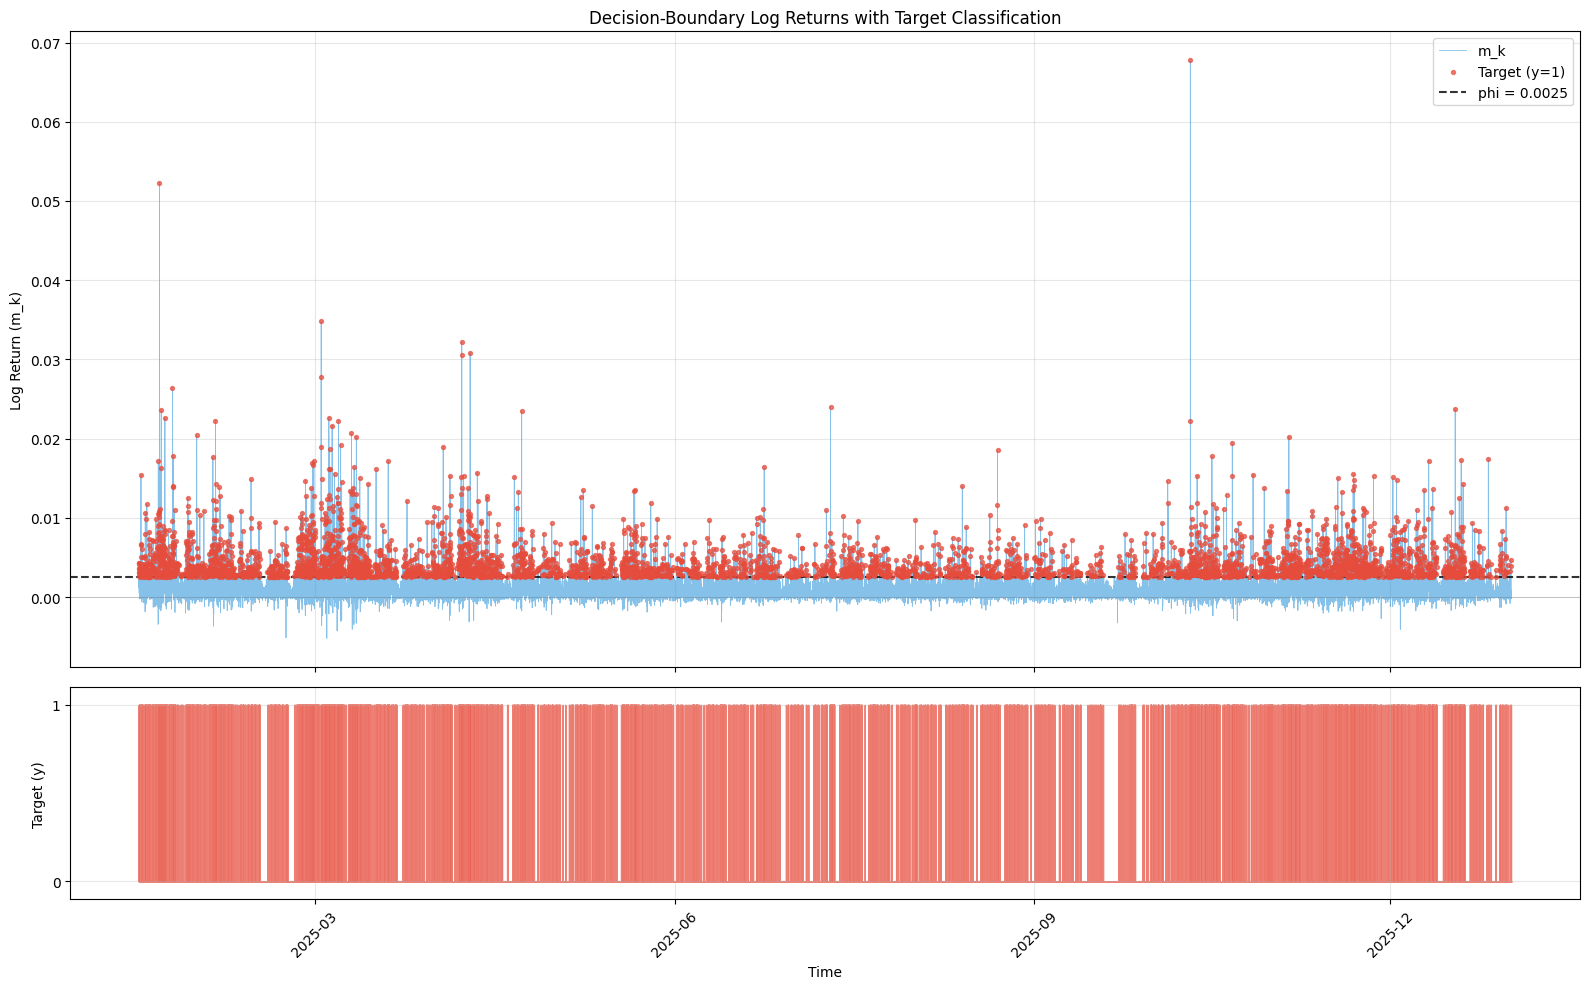


Monthly target distribution:
          hits  total  base_rate
_month                          
2025-01  366.0   1224      0.299
2025-02  467.0   2016      0.232
2025-03  588.0   2232      0.263
2025-04  477.0   2160      0.221
2025-05  360.0   2232      0.161
2025-06  259.0   2160      0.120
2025-07  264.0   2232      0.118
2025-08  242.0   2232      0.108
2025-09  155.0   2160      0.072
2025-10  421.0   2232      0.189
2025-11  532.0   2160      0.246
2025-12  394.0   2231      0.177


In [7]:
import matplotlib.dates as mdates

ts = pd.to_datetime(df_final['ts'])
fig, axes = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

ax1 = axes[0]
ax1.plot(ts, m_k, color='#3498db', alpha=0.6, linewidth=0.6, label='m_k')
pos_mask = y == 1
ax1.scatter(ts[pos_mask], m_k[pos_mask], color='#e74c3c', s=8, alpha=0.7,
            label='Target (y=1)', zorder=5, marker='o')
ax1.axhline(phi, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label=f'phi = {phi:.4f}')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax1.set_ylabel('Log Return (m_k)')
ax1.set_title('Decision-Boundary Log Returns with Target Classification')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(ts, y, step='mid', alpha=0.7, color='#e74c3c', label='Target (y)')
ax2.set_ylabel('Target (y)')
ax2.set_xlabel('Time')
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly = (
    df_final.assign(_month=ts.dt.to_period('M'))
    .groupby('_month')['y']
    .agg(['sum', 'count', 'mean'])
    .round(3)
)
monthly.columns = ['hits', 'total', 'base_rate']
print()
print('Monthly target distribution:')
print(monthly.to_string())


---

# Inspection: feature-set quality, target & weights

Everything below operates on the saved final dataset. Helpers come from `src.features.observability`. Plots land inline.

Sections:
- **E1** Feature health — per-feature stats + issues table
- **E2** Family summary — aggregate by column-name family
- **E3** Weight profile — weight as a function of m_k (legacy plot)
- **E4** Weight distribution — class-conditional histograms (legacy plot)
- **E5** Target stability — monthly base rate over time


## E1 — Feature health

Per-feature stats: `nan_rate` (post-impute, should be 0), `undef_rate` (pre-impute null rate read from `undef__<col>` flags), distribution stats (mean/std/skew/kurt), and issue flags (constant, inf, heavy_skew, high_undef, all_nan).


In [8]:
from src.features.observability import (
    compute_feature_health,
    flag_issues,
    summarize_by_family,
    monthly_target_balance,
)

# Build the feature-column list: everything except labels, weights,
# undef flags, raw bars, base series, and derivatives base series.
_LABEL_AUX = {'k', 'ts', 'y', 'm_k', 'tau_k', 'phi'}
_WEIGHT_AUX = {'w_dist', 'w_time', 'weight'}
_RAW = set(RAW_COLS)
_BASE = set(BASE_COLS)
_DERIV_BASE = set(DERIV_BASE_COLS)
_NON_FEATURE = _LABEL_AUX | _WEIGHT_AUX | _RAW | _BASE | _DERIV_BASE

feature_cols_for_health = [
    c for c in df_final_pl.columns
    if c not in _NON_FEATURE and not c.startswith('undef__')
]

health = compute_feature_health(df_final_pl, feature_cols_for_health)
issues = flag_issues(health, max_undef_rate=0.5, max_abs_skew=20.0)

n_total = len(health)
n_residual_nan      = int((health['n_nan'] > 0).sum())
n_with_inf          = int(health['has_inf'].sum())
n_scattered         = int((health['null_pattern'] == 'scattered').sum())
n_imputed_constant  = int(health['is_imputed_constant'].sum())
n_organic_constant  = int(health['is_organic_constant'].sum())
n_extreme_outlier   = int(health['is_extreme_outlier'].sum())
n_non_stationary    = int(health['is_non_stationary'].sum())
n_undef_any         = int((health['undef_rate'] > 0).sum())

print(f'Total feature columns inspected: {n_total:,}')
print(f'  HARD-FAIL  residual float NaN:     {n_residual_nan}')
print(f'  HARD-FAIL  +/- inf:                {n_with_inf}')
print(f'  HARD-FAIL  scattered missing:      {n_scattered}')
print(f'  WARN       imputed constant:       {n_imputed_constant}   (drop candidates)')
print(f'  WARN       extreme outlier:        {n_extreme_outlier}   (winsorize candidates)')
print(f'  WARN       non-stationary:         {n_non_stationary}   (regime monitoring)')
print(f'  INFO       organic constant:       {n_organic_constant}   (by-design scalars)')
print(f'  INFO       non-zero undef rate:    {n_undef_any}')
print()

# Pattern breakdown — captures whether missingness is at the edges
# (warmup / coverage tail) or scattered (data anomaly / engine bug).
pattern_counts = (
    health.group_by('null_pattern').agg(pl.len().alias('n')).sort('n', descending=True)
)
print('Nullability pattern breakdown:')
print(pattern_counts)
print()

# Issue table
print(f'Features flagged by flag_issues(): {len(issues):,}')
if len(issues) > 0:
    print()
    print('Issue table (sorted by priority + outlier ratio):')
    print(issues.select([
        'name', 'family', 'issue', 'null_pattern',
        'undef_rate', 'outlier_ratio', 'mean_drift_chunks',
        'std_drift_ratio_chunks',
    ]).head(40))

# Hard-fail gate. The first three categories are dataset-blocking; the
# WARN categories surface for the ML team to triage in the training
# notebook (drop / winsorize / regime-aware CV).
hard_fail = {
    'residual_nan':       int((issues['issue'] == 'residual_nan').sum()) if len(issues) else 0,
    'inf':                int((issues['issue'] == 'inf').sum()) if len(issues) else 0,
    'scattered_missing':  int((issues['issue'] == 'scattered_missing').sum()) if len(issues) else 0,
}
if any(v > 0 for v in hard_fail.values()):
    print()
    print('!!! HARD-FAIL: dataset is not safe to ship — ', hard_fail)
else:
    print()
    print('OK: zero residual NaN, zero inf, zero scattered-missing.')


Total feature columns inspected: 1,236
  HARD-FAIL  residual float NaN:     0
  HARD-FAIL  +/- inf:                0
  HARD-FAIL  scattered missing:      0
  WARN       imputed constant:       5   (drop candidates)
  WARN       extreme outlier:        3   (winsorize candidates)
  WARN       non-stationary:         49   (regime monitoring)
  INFO       organic constant:       4   (by-design scalars)
  INFO       non-zero undef rate:    15

Nullability pattern breakdown:
shape: (1, 2)
┌──────────────┬──────┐
│ null_pattern ┆ n    │
│ ---          ┆ ---  │
│ str          ┆ u32  │
╞══════════════╪══════╡
│ clean        ┆ 1236 │
└──────────────┴──────┘

Features flagged by flag_issues(): 70

Issue table (sorted by priority + outlier ratio):
shape: (40, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ name       ┆ family     ┆ issue      ┆ null_patt ┆ undef_rat ┆ outlier_r ┆ mean_drif ┆ std_drift │
│ ---        ┆ ---        ┆ ---      

## E2 — Family summary

Aggregates per family (column-name prefix). Useful to see which families dominate the column count and whether any family has unusual NaN/skew/constant counts.


shape: (37, 14)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ family    ┆ n_feature ┆ avg_undef ┆ max_undef ┆ … ┆ n_non_sta ┆ n_with_in ┆ avg_std   ┆ avg_abs_ │
│ ---       ┆ s         ┆ _rate     ┆ _rate     ┆   ┆ tionary   ┆ f         ┆ ---       ┆ skew     │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ ---      │
│           ┆ u32       ┆ f64       ┆ f64       ┆   ┆ u32       ┆ u32       ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ ret       ┆ 332       ┆ 0.0       ┆ 0.0       ┆ … ┆ 16        ┆ 0         ┆ 0.295875  ┆ 2.233949 │
│ ofi       ┆ 136       ┆ 0.0       ┆ 0.0       ┆ … ┆ 3         ┆ 0         ┆ 0.303311  ┆ 0.357632 │
│ vol       ┆ 129       ┆ 0.0       ┆ 0.0       ┆ … ┆ 6         ┆ 0         ┆ 0.164856  ┆ 5.264884 │
│ logvol    ┆ 122       ┆ 0.0       ┆ 0.0       ┆ … ┆ 5         ┆ 0        

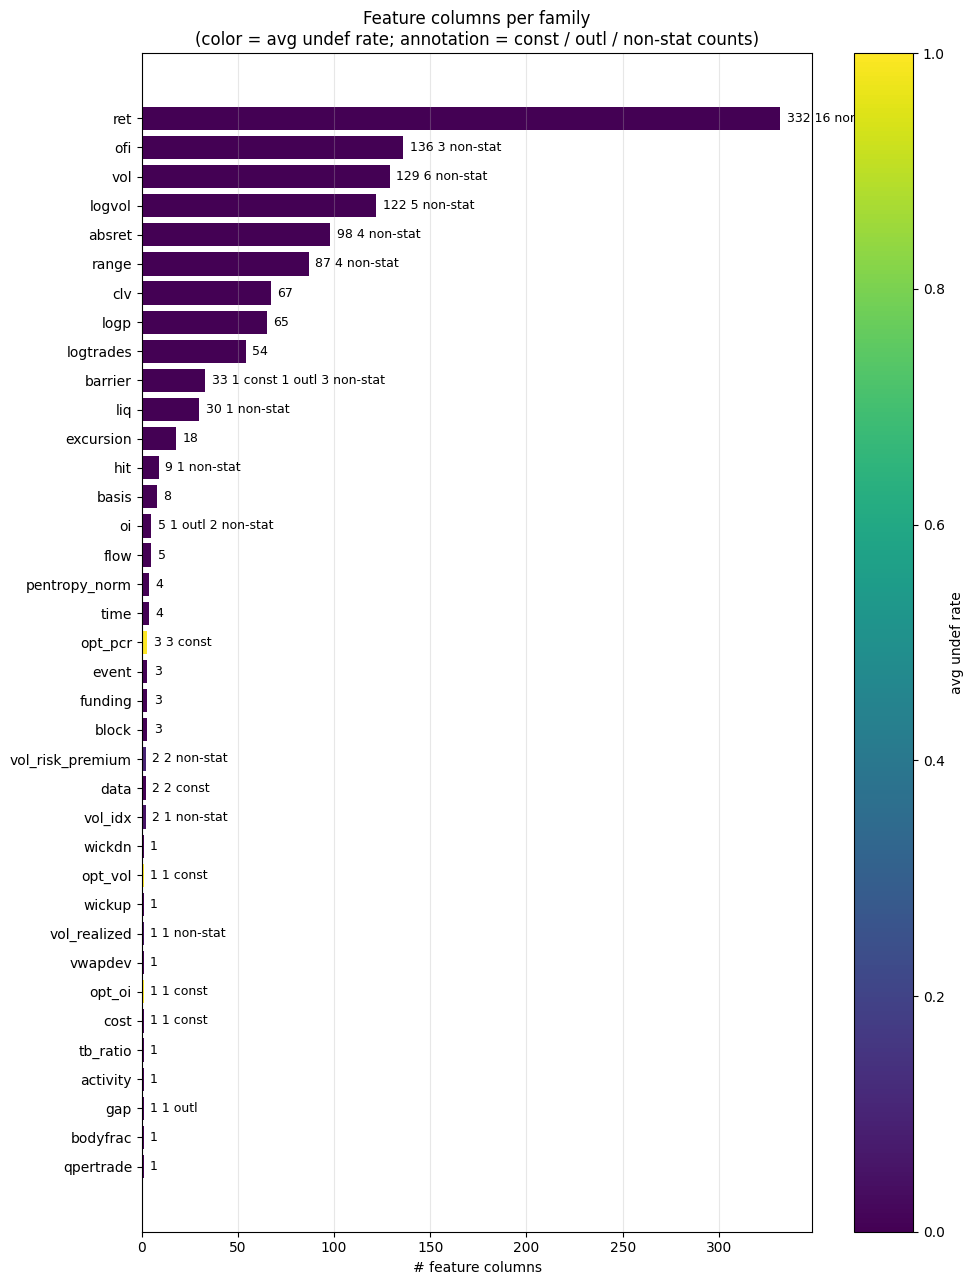

In [9]:
fam_summary = summarize_by_family(health)
print(fam_summary)

# Horizontal bar chart: feature count per family, colored by avg undef rate
import matplotlib.pyplot as plt
from matplotlib import cm

fam_pd = fam_summary.to_pandas().sort_values('n_features', ascending=True)
# Total constants = imputed + organic (the family summary now splits them).
fam_pd['n_constant'] = fam_pd['n_imputed_constant'] + fam_pd['n_organic_constant']

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(fam_pd))))
vmax = max(0.001, float(fam_pd['avg_undef_rate'].max()))
colors = cm.viridis(fam_pd['avg_undef_rate'] / vmax)
ax.barh(fam_pd['family'], fam_pd['n_features'], color=colors)

for i, (n, undef, n_const, n_out, n_ns) in enumerate(zip(
    fam_pd['n_features'],
    fam_pd['avg_undef_rate'],
    fam_pd['n_constant'],
    fam_pd['n_extreme_outlier'],
    fam_pd['n_non_stationary'],
)):
    annot = [f'{n}']
    if n_const:
        annot.append(f'{n_const} const')
    if n_out:
        annot.append(f'{n_out} outl')
    if n_ns:
        annot.append(f'{n_ns} non-stat')
    ax.text(n + max(fam_pd['n_features']) * 0.01, i,
            ' '.join(annot), va='center', fontsize=9)

ax.set_xlabel('# feature columns')
ax.set_title('Feature columns per family\n(color = avg undef rate; annotation = const / outl / non-stat counts)')
ax.grid(True, axis='x', alpha=0.3)
sm = cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='avg undef rate')
plt.tight_layout()
plt.show()


## E3 — Weight profile (legacy plot)

`utils.plot_weight_profiles` shows how the per-sample weight depends on the realised barrier distance `m_k − phi`. Negative-class samples whose `m_k` is far below `phi` get larger weights up to the cap; positive-class samples optionally get an upside profile when `WEIGHT_DIST_USE_POSITIVE` is on. The legacy plotting helper is reused as-is — no port needed.


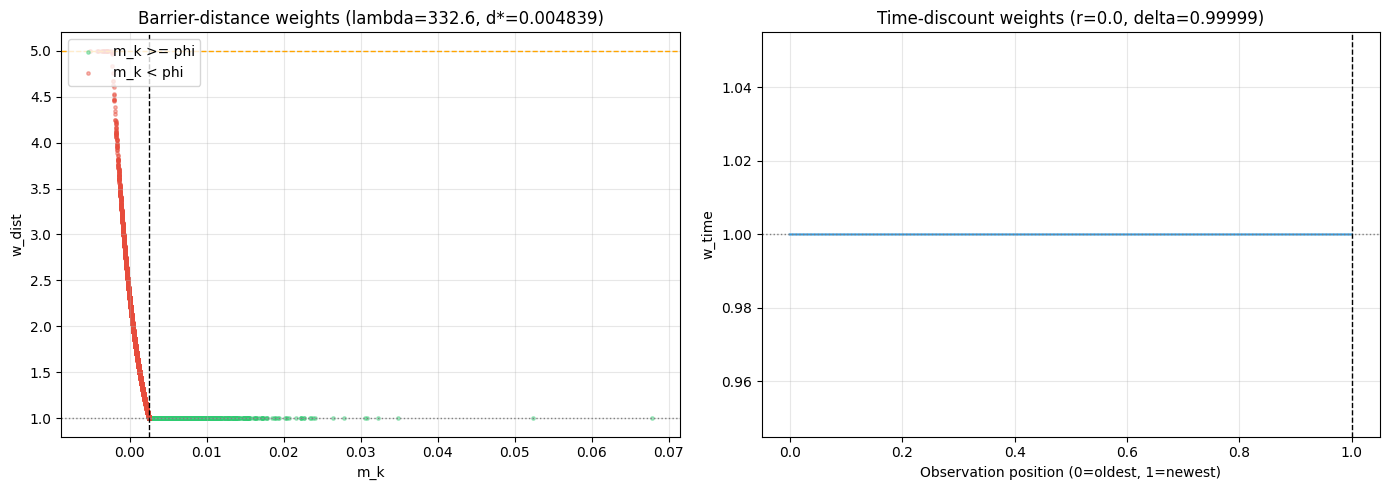

In [10]:
import matplotlib.pyplot as plt

m_k_arr = df_final_pl['m_k'].to_numpy()
phi_val = float(df_final_pl['phi'][0])
w_dist_arr = df_final_pl['w_dist'].to_numpy()
w_time_arr = df_final_pl['w_time'].to_numpy()
k_arr = df_final_pl['k'].to_numpy()

fig_profiles = utils.plot_weight_profiles(
    m_k=m_k_arr,
    phi=phi_val,
    w_dist=w_dist_arr,
    w_time=w_time_arr,
    k_index=k_arr,
    info=weight_info,
)
plt.show()


## E4 — Weight distribution by class (legacy plot)

`utils.plot_weight_distributions` shows histograms of `w_dist`, `w_time`, and the combined `weight`, split by class. A large divergence between class histograms indicates that the weighting actively rebalances — a sanity check on whether the weight scheme matters for this dataset.


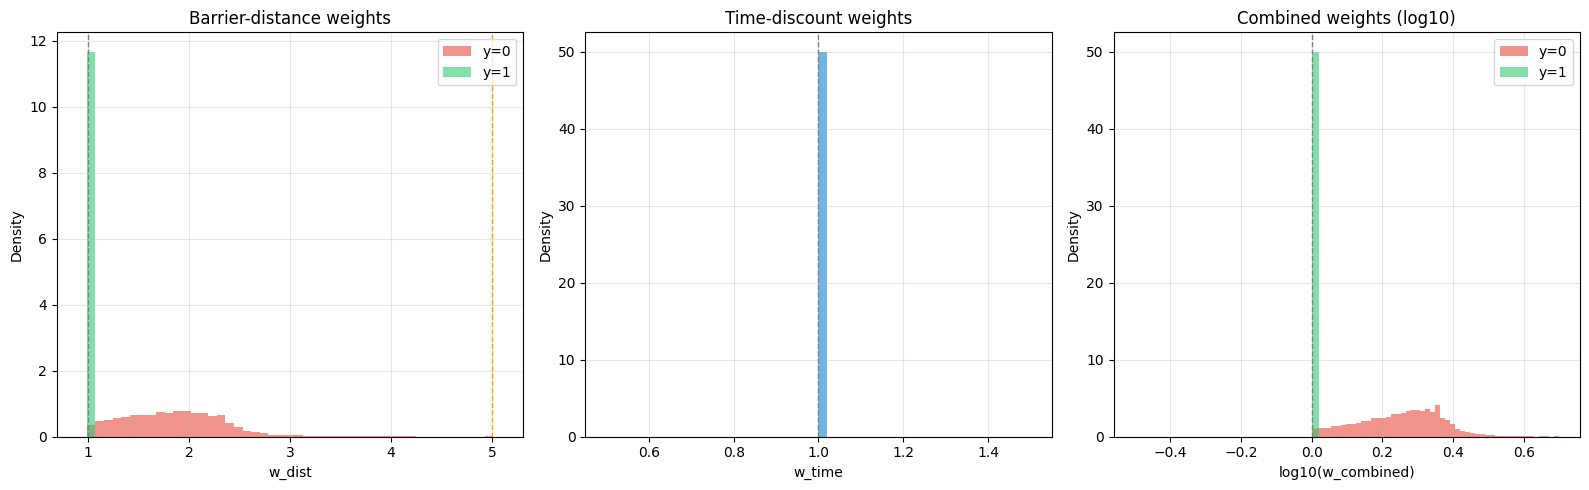

In [11]:
import matplotlib.pyplot as plt

w_combined_arr = df_final_pl['weight'].to_numpy()
y_arr = df_final_pl['y'].to_numpy()

fig_dists = utils.plot_weight_distributions(
    w_dist=w_dist_arr,
    w_time=w_time_arr,
    w_combined=w_combined_arr,
    y=y_arr,
    info=weight_info,
)
plt.show()


## E5 — Target stability over time

Monthly base rate (= mean of `y` per month) and total sample count. Drift in base rate signals regime change in the underlying barrier-crossing dynamics; sharp drops in total count signal data gaps.


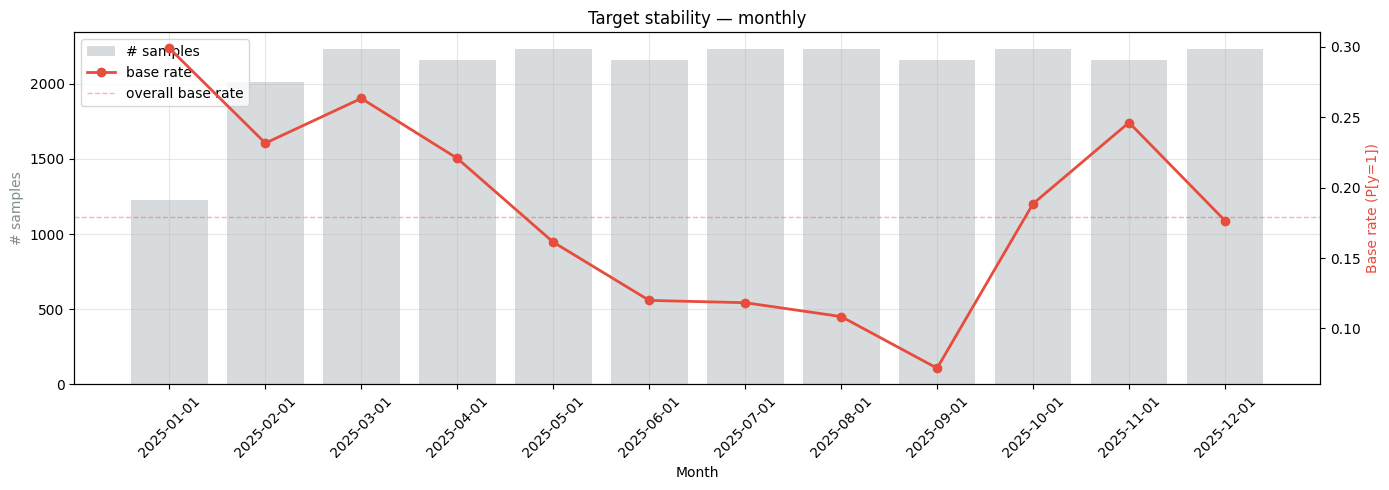


Per-month summary:
    _month  total  hits  base_rate
2025-01-01   1224 366.0   0.299020
2025-02-01   2016 467.0   0.231647
2025-03-01   2232 588.0   0.263441
2025-04-01   2160 477.0   0.220833
2025-05-01   2232 360.0   0.161290
2025-06-01   2160 259.0   0.119907
2025-07-01   2232 264.0   0.118280
2025-08-01   2232 242.0   0.108423
2025-09-01   2160 155.0   0.071759
2025-10-01   2232 421.0   0.188620
2025-11-01   2160 532.0   0.246296
2025-12-01   2231 394.0   0.176602


In [12]:
import matplotlib.pyplot as plt

monthly = monthly_target_balance(df_final_pl).to_pandas()
monthly['_month'] = monthly['_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['_month'], monthly['total'], color='#bdc3c7', alpha=0.6, label='# samples')
ax2.plot(monthly['_month'], monthly['base_rate'],
         color='#e74c3c', marker='o', linewidth=2, label='base rate')
ax2.axhline(
    float(df_final_pl['y'].mean()),
    color='#e74c3c', linestyle='--', alpha=0.4, linewidth=1,
    label='overall base rate',
)

ax1.set_xlabel('Month')
ax1.set_ylabel('# samples', color='#7f8c8d')
ax2.set_ylabel('Base rate (P[y=1])', color='#e74c3c')
ax1.set_title('Target stability — monthly')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print()
print('Per-month summary:')
print(monthly.to_string(index=False))
